In [1]:
# Feature Engineering for Machine Learning

In [2]:
import pandas as pd
import warnings 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
warnings.filterwarnings("ignore")

stack_df = pd.read_csv('Data/stack_overflow.csv')
stack_df.head()

,SurveyDate,FormalEducation,ConvertedSalary,Hobby,Country,StackOverflowJobsRecommend,VersionControl,Age,Years Experience,Gender,RawSalary
0,2/28/18 20:20,Bachelor's degree (BA. BS. B.Eng.. etc.),NaN,Yes,South Africa,NaN,Git,21,13,Male,NaN
1,6/28/18 13:26,Bachelor's degree (BA. BS. B.Eng.. etc.),70841.0,Yes,Sweeden,7.0,Git;Subversion,38,9,Male,"70,841.00"
2,6/6/18 3:37,Bachelor's degree (BA. BS. B.Eng.. etc.),NaN,No,Sweeden,8.0,Git,45,11,NaN,NaN
3,5/9/18 1:06,Some college/university study without earning ...,21426.0,Yes,Sweeden,NaN,Zip file back-ups,46,12,Male,"21,426.00"
4,4/12/18 22:41,Bachelor's degree (BA. BS. B.Eng.. etc.),41671.0,Yes,UK,8.0,Git,39,7,Male,"£41,671.00"


In [3]:
stack_df.shape

(999, 11)

In [4]:
# Create subset of only the numeric columns
so_numeric_df = stack_df.select_dtypes(include=['int', 'float'])

# Print the column names contained in so_survey_df_num
print(so_numeric_df.columns)

Index(['ConvertedSalary', 'StackOverflowJobsRecommend', 'Age',
       'Years Experience'],
      dtype='object')


In [5]:
stack_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   SurveyDate                  999 non-null    object 
 1   FormalEducation             999 non-null    object 
 2   ConvertedSalary             665 non-null    float64
 3   Hobby                       999 non-null    object 
 4   Country                     999 non-null    object 
 5   StackOverflowJobsRecommend  487 non-null    float64
 6   VersionControl              999 non-null    object 
 7   Age                         999 non-null    int64  
 8   Years Experience            999 non-null    int64  
 9   Gender                      693 non-null    object 
 10  RawSalary                   665 non-null    object 
dtypes: float64(2), int64(2), object(7)
memory usage: 86.0+ KB


In [6]:
# Convert the Country column to a one hot encoded Data Frame
one_hot_encoded = pd.get_dummies(stack_df, columns=['Country'], prefix='OH')

# Print the columns names
print(one_hot_encoded.columns)

Index(['SurveyDate', 'FormalEducation', 'ConvertedSalary', 'Hobby',
       'StackOverflowJobsRecommend', 'VersionControl', 'Age',
       'Years Experience', 'Gender', 'RawSalary', 'OH_France', 'OH_India',
       'OH_Ireland', 'OH_Russia', 'OH_South Africa', 'OH_Spain', 'OH_Sweeden',
       'OH_UK', 'OH_USA', 'OH_Ukraine'],
      dtype='object')


In [7]:
# Create dummy variables for the Country column
dummy = pd.get_dummies(stack_df, columns=['Country'], drop_first=True, prefix='DM')

# Print the columns names
print(dummy.columns)

Index(['SurveyDate', 'FormalEducation', 'ConvertedSalary', 'Hobby',
       'StackOverflowJobsRecommend', 'VersionControl', 'Age',
       'Years Experience', 'Gender', 'RawSalary', 'DM_India', 'DM_Ireland',
       'DM_Russia', 'DM_South Africa', 'DM_Spain', 'DM_Sweeden', 'DM_UK',
       'DM_USA', 'DM_Ukraine'],
      dtype='object')


In [8]:
# Create a series out of the Country column
countries = stack_df['Country']

# Get the counts of each category
country_counts = countries.value_counts()

# Create a mask for only categories that occur less than 10 times
mask = countries.isin(country_counts[country_counts < 10].index)

print(mask.head())

0    False
1    False
2    False
3    False
4    False
Name: Country, dtype: bool


In [9]:
# Label all other categories as Other
countries[mask] = 'Other'

# Print the updated category counts
print(pd.value_counts(countries))

Country
South Africa    166
USA             164
Spain           134
Sweeden         119
France          115
Russia           97
UK               95
India            95
Other            14
Name: count, dtype: int64


In [10]:
#Dropping missing values
stack_df = stack_df.dropna(subset=['ConvertedSalary'])

# Create the Paid_Job column filled with zeros
stack_df['Paid_Job'] = 0

# Replace all the Paid_Job values where ConvertedSalary is > 0
stack_df.loc[stack_df['ConvertedSalary'] > 0, 'Paid_Job'] = 1

# Print the first five rows of the columns
print(stack_df[['Paid_Job', 'ConvertedSalary']].head())

   Paid_Job  ConvertedSalary
1         1          70841.0
3         1          21426.0
4         1          41671.0
5         1         120000.0
7         1         250000.0


In [11]:
# Bin the continuous variable ConvertedSalary into 5 bins
stack_df['equal_binned'] = pd.cut(stack_df['ConvertedSalary'], 5)

# Print the first 5 rows of the equal_binned column
print(stack_df[['equal_binned', 'ConvertedSalary']])

              equal_binned  ConvertedSalary
1      (-2000.0, 400000.0]          70841.0
3      (-2000.0, 400000.0]          21426.0
4      (-2000.0, 400000.0]          41671.0
5      (-2000.0, 400000.0]         120000.0
7      (-2000.0, 400000.0]         250000.0
..                     ...              ...
991    (-2000.0, 400000.0]          55562.0
993    (-2000.0, 400000.0]          30000.0
995    (-2000.0, 400000.0]          58746.0
996    (-2000.0, 400000.0]          55000.0
998  (800000.0, 1200000.0]        1000000.0

[665 rows x 2 columns]


In [12]:
# Specify the boundaries of the bins
bins = [-np.inf, 10000, 50000, 100000, 150000, np.inf]

# Bin labels
labels = ['Very low', 'Low', 'Medium', 'High', 'Very high']

# Bin the continuous variable ConvertedSalary using these boundaries
stack_df['boundary_binned'] = pd.cut(stack_df['ConvertedSalary'], 
                                         bins, labels = labels)

# Print the first 5 rows of the boundary_binned column
print(stack_df[['boundary_binned', 'ConvertedSalary']].head())

  boundary_binned  ConvertedSalary
1          Medium          70841.0
3             Low          21426.0
4             Low          41671.0
5            High         120000.0
7       Very high         250000.0


In [13]:
sub_df = stack_df[['Age', 'Gender']]

sub_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 665 entries, 1 to 998
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Age     665 non-null    int64 
 1   Gender  467 non-null    object
dtypes: int64(1), object(1)
memory usage: 15.6+ KB


In [14]:
sub_df.notnull()

,Age,Gender
1,True,True
3,True,True
4,True,True
5,True,True
7,True,True
...,...,...
991,True,False
993,True,True
995,True,True
996,True,True


In [15]:
stack_df = pd.read_csv('Data/stack_overflow.csv')
stack_df.shape

(999, 11)

In [16]:
# Create a new DataFrame dropping all incomplete rows
no_missing_values_rows = stack_df.dropna()

# Print the shape of the new DataFrame
print(no_missing_values_rows.shape)

(264, 11)


In [17]:
# Create a new DataFrame dropping all columns with incomplete rows
no_missing_values_cols = stack_df.dropna(axis=1)

# Print the shape of the new DataFrame
print(no_missing_values_cols.shape)

(999, 7)


In [18]:
# Drop all rows where Gender is missing
no_gender = stack_df.dropna(subset=['Gender'])

# Print the shape of the new DataFrame
print(no_gender.shape)

(693, 11)


In [19]:
# Print the count of occurrences
print(stack_df['Gender'].value_counts())

print("-------------")

# Replace missing values
stack_df['Gender'].fillna('Not Given', inplace = True)

# Print the count of each value
print(stack_df['Gender'].value_counts())

Gender
Male                                                                         632
Female                                                                        53
Female;Male                                                                    2
Transgender                                                                    2
Female;Male;Transgender;Non-binary. genderqueer. or gender non-conforming      1
Male;Non-binary. genderqueer. or gender non-conforming                         1
Non-binary. genderqueer. or gender non-conforming                              1
Female;Transgender                                                             1
Name: count, dtype: int64
-------------
Gender
Male                                                                         632
Not Given                                                                    306
Female                                                                        53
Female;Male                                            

In [20]:
# Fill missing values with the mean
stack_df['StackOverflowJobsRecommend'].fillna(stack_df['StackOverflowJobsRecommend'].mean(), inplace=True)

# Round the StackOverflowJobsRecommend values
stack_df['StackOverflowJobsRecommend'] = round(stack_df['StackOverflowJobsRecommend'])

# Print the top 5 rows
print(stack_df['StackOverflowJobsRecommend'].head())

0    7.0
1    7.0
2    8.0
3    7.0
4    8.0
Name: StackOverflowJobsRecommend, dtype: float64


In [21]:
stack_df['RawSalary'].dtype

dtype('O')

In [22]:
stack_df['RawSalary'].head(10)

0           NaN
1     70,841.00
2           NaN
3     21,426.00
4    £41,671.00
5    120,000.00
6           NaN
7    250,000.00
8           NaN
9          0.00
Name: RawSalary, dtype: object

In [23]:
# Remove the commas in the column
stack_df['RawSalary'] = stack_df['RawSalary'].str.replace(',', '')

# Remove the dollar signs in the column
stack_df['RawSalary'] = stack_df['RawSalary'].str.replace('£', '')
stack_df['RawSalary'].head()

0         NaN
1    70841.00
2         NaN
3    21426.00
4    41671.00
Name: RawSalary, dtype: object

In [24]:
# Attempt to convert the column to numeric values
numeric_vals = pd.to_numeric(stack_df['RawSalary'], errors='coerce')

print(numeric_vals.isna())


0       True
1      False
2       True
3      False
4      False
       ...  
994     True
995    False
996     True
997     True
998    False
Name: RawSalary, Length: 999, dtype: bool


In [25]:
# Find the indexes of missing values
idx = numeric_vals.isna()

# Print the relevant rows
print(stack_df['RawSalary'][idx])

0            NaN
2            NaN
6            NaN
8            NaN
11           NaN
         ...    
990          NaN
992          NaN
994          NaN
996    $55000.00
997          NaN
Name: RawSalary, Length: 439, dtype: object


In [26]:
# Replace the offending characters
stack_df['RawSalary'] = stack_df['RawSalary'].str.replace('£', '')
stack_df['RawSalary'] = stack_df['RawSalary'].str.replace('$', '')
# Convert the column to float
stack_df['RawSalary'] = stack_df['RawSalary'].astype('float')

# Print the column
print(stack_df['RawSalary'])

0            NaN
1        70841.0
2            NaN
3        21426.0
4        41671.0
         ...    
994          NaN
995      58746.0
996      55000.0
997          NaN
998    1000000.0
Name: RawSalary, Length: 999, dtype: float64


In [27]:
# Fill missing values with the mean
stack_df['RawSalary'].fillna(stack_df['RawSalary'].mean(), inplace=True)
# Print the column
print(stack_df['RawSalary'].isna().sum())

0


In [28]:
# # Use method chaining
# stack_df['RawSalary'] = stack_df['RawSalary']\
#                               .str.replace(',','')\
#                               .str.replace('$','')\
#                               .str.replace('£', '')\
#                               .astype('float')
 
# # Print the RawSalary column
# print(stack_df['RawSalary'])

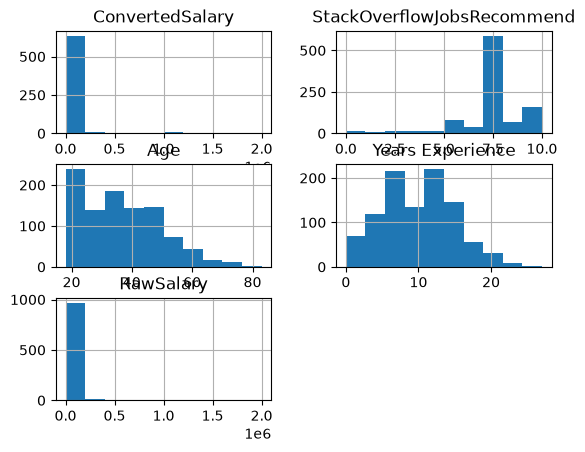

In [29]:
stack_df.hist()
plt.show()

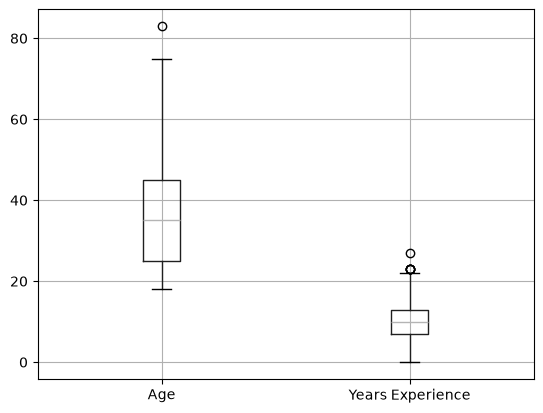

In [30]:
# Create a boxplot of two columns
stack_df[['Age', 'Years Experience']].boxplot()
plt.show()

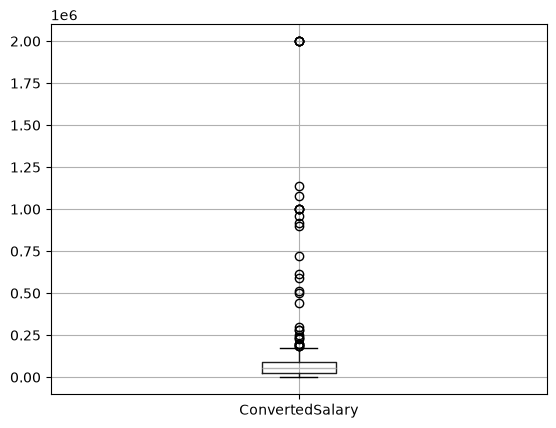

In [31]:
# Create a boxplot of ConvertedSalary
so_numeric_df[['ConvertedSalary']].boxplot()
plt.show()

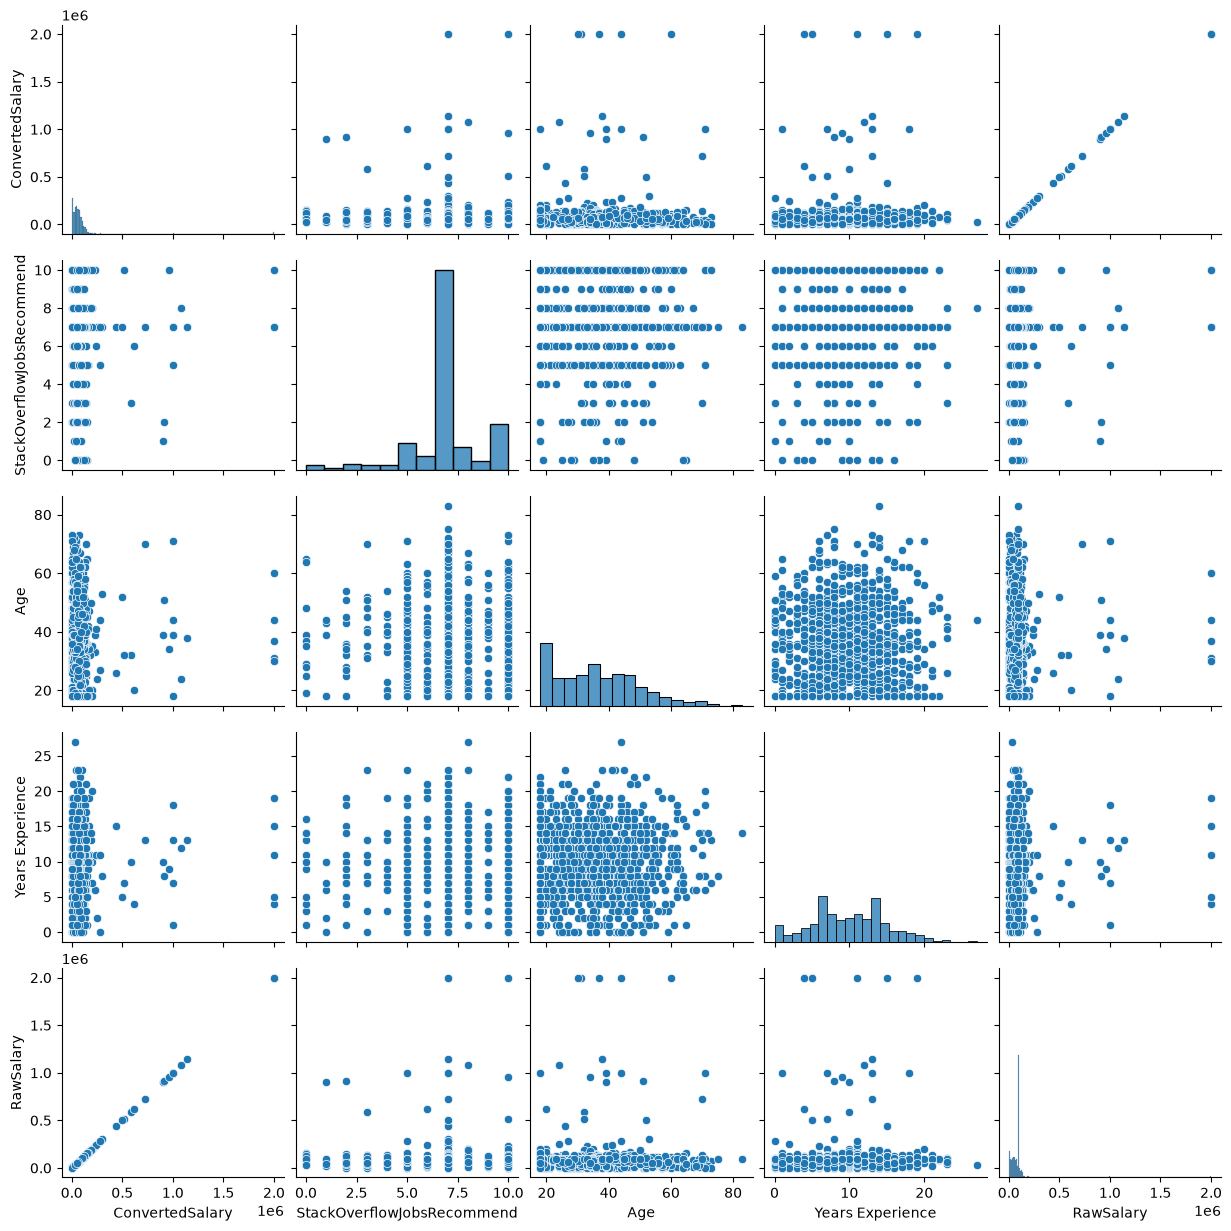

In [32]:
# Plot pairwise relationships
sns.pairplot(stack_df)

# Show plot
plt.show()

In [33]:
# Instantiate MinMaxScaler
MM_scaler = MinMaxScaler()

# Fit MM_scaler to the data
MM_scaler.fit(stack_df[['Age']])

# Transform the data using the fitted scaler
stack_df['Age_MM'] = MM_scaler.transform(stack_df[['Age']])

# Compare the origional and transformed column
print(stack_df[['Age_MM', 'Age']].head())

     Age_MM  Age
0  0.046154   21
1  0.307692   38
2  0.415385   45
3  0.430769   46
4  0.323077   39


In [34]:
# Instantiate StandardScaler
SS_scaler = StandardScaler()

# Fit SS_scaler to the data
SS_scaler.fit(stack_df[['Age']])

# Transform the data using the fitted scaler
stack_df['Age_SS'] = SS_scaler.transform(stack_df[['Age']])

# Compare the origional and transformed column
print(stack_df[['Age_SS', 'Age']].head())

     Age_SS  Age
0 -1.132431   21
1  0.150734   38
2  0.679096   45
3  0.754576   46
4  0.226214   39


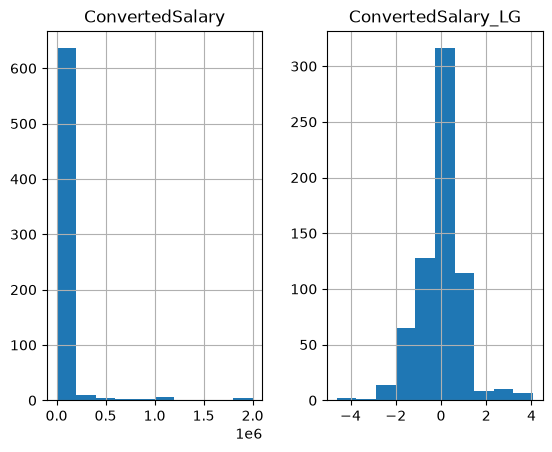

In [35]:
# Instantiate PowerTransformer
pow_trans = PowerTransformer()

# Train the transform on the data
pow_trans.fit(stack_df[['ConvertedSalary']])

# Apply the power transform to the stack_df
stack_df['ConvertedSalary_LG'] = pow_trans.transform(stack_df[['ConvertedSalary']])

# Plot the data before and after the transformation
stack_df[['ConvertedSalary', 'ConvertedSalary_LG']].hist()
plt.show()

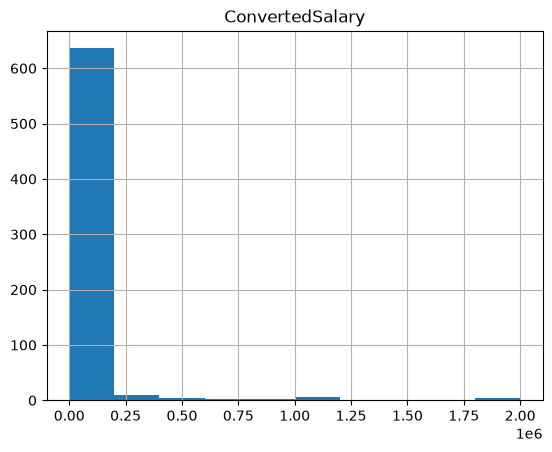

<Figure size 640x480 with 0 Axes>

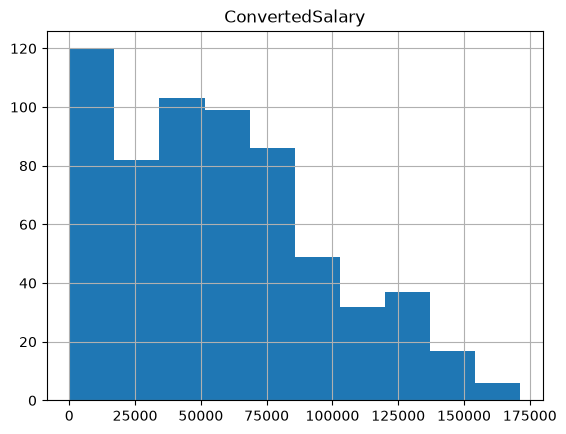

In [36]:
# Find the 95th quantile
quantile = stack_df['ConvertedSalary'].quantile(0.95)

# Trim the outliers
trimmed_df = stack_df[stack_df['ConvertedSalary'] < quantile]

# The original histogram
stack_df[['ConvertedSalary']].hist()
plt.show()
plt.clf()

# The trimmed histogram
trimmed_df[['ConvertedSalary']].hist()
plt.show()

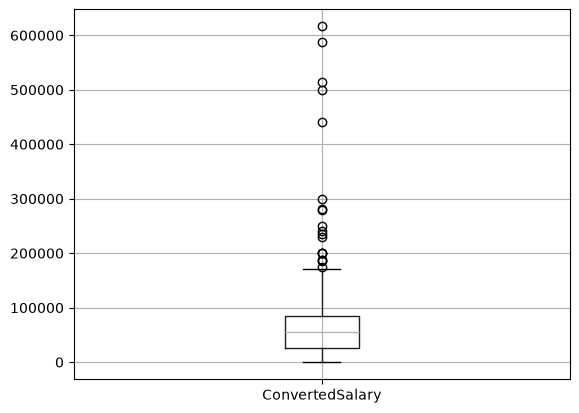

In [37]:
# Find the mean and standard dev
std = stack_df['ConvertedSalary'].std()
mean = stack_df['ConvertedSalary'].mean()

# Calculate the cutoff
cut_off = std * 3
lower, upper = mean - cut_off, mean + cut_off

# Trim the outliers
trimmed_df = stack_df[(stack_df['ConvertedSalary'] < upper) \
                           & (stack_df['ConvertedSalary'] > lower)]

# The trimmed box plot
trimmed_df[['ConvertedSalary']].boxplot()
plt.show()

In [38]:
# Split so_numeric_df into train and test sets
so_train_numeric, so_test_numeric = train_test_split(stack_df, test_size=0.3, random_state=42)

print(so_train_numeric.shape)
print(so_test_numeric.shape)

(699, 14)
(300, 14)


In [39]:
# Apply a standard scaler to the data
SS_scaler = StandardScaler()

# Fit the standard scaler to the data
SS_scaler.fit(so_train_numeric[['Age']])

# Transform the test data using the fitted scaler
so_test_numeric['Age_ss'] = SS_scaler.transform(so_test_numeric[['Age']])
print(so_test_numeric[['Age', 'Age_ss']].head())

     Age    Age_ss
453   29 -0.527031
793   25 -0.832435
209   46  0.770939
309   18 -1.366893
740   26 -0.756084


In [40]:
train_std = so_train_numeric['ConvertedSalary'].std()
train_mean = so_train_numeric['ConvertedSalary'].mean()

cut_off = train_std * 3
train_lower, train_upper = train_mean - cut_off, train_mean + cut_off

# Trim the test DataFrame
trimmed_df = so_test_numeric[(so_test_numeric['ConvertedSalary'] < train_upper) \
                             & (so_test_numeric['ConvertedSalary'] > train_lower)]